# Two-Stage CNN Pipeline — Training

Stage 1: Classify structure type (Decks / Pavements / Walls)

Stage 2: Classify defect / no_defect per structure (recall-optimised)

Primary metric: Recall (minimise false negatives). Secondary: confusion matrix, ROC-AUC, F1.

Crack localisation: The dataset contains image-level labels only — no bounding boxes, polygons, or masks exist under data/. Drawing crack boxes from these labels is not possible; no boxes are invented. See pipeline_eval.ipynb for Grad-CAM attention heatmaps (non-localization exploratory visualisation).

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, f1_score, roc_auc_score, confusion_matrix
import json
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.16.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Constants & Data Scan

In [2]:
# ── Set FAST_MODE = True to train in ~20 min on CPU (2 epochs, 25% data) ──
FAST_MODE = False

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
DATA_DIR = Path('data')
STRUCTURES = ['Decks', 'Pavements', 'Walls']
AUTOTUNE = tf.data.AUTOTUNE

EPOCHS_HEAD = 2 if FAST_MODE else 5
EPOCHS_FT   = 2 if FAST_MODE else 5
SAMPLE_FRAC = 0.25 if FAST_MODE else 1.0

print(f'FAST_MODE={FAST_MODE}  epochs={EPOCHS_HEAD}+{EPOCHS_FT}  sample={SAMPLE_FRAC:.0%}')

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Scan all image paths with metadata
records = []
for struct_idx, struct in enumerate(STRUCTURES):
    for defect_class in ['defect', 'no_defect']:
        folder = DATA_DIR / struct / defect_class
        for img_path in sorted(folder.glob('*.jpg')):
            # Filenames follow <sceneID>-<frame>.jpg; group by sceneID to avoid leakage
            scene_id = img_path.stem.split('-')[0]
            records.append({
                'path': str(img_path),
                'structure': struct,
                'label': defect_class,
                'scene_id': scene_id,
                'structure_idx': struct_idx,
                'defect_idx': 1 if defect_class == 'defect' else 0,
            })

df = pd.DataFrame(records)
print(f'Total images: {len(df)}')
print()
print(df.groupby(['structure', 'label']).size().unstack(fill_value=0))

FAST_MODE=False  epochs=5+5  sample=100%
Total images: 56092

label      defect  no_defect
structure                   
Decks        2025      11595
Pavements    2608      21726
Walls        3851      14287


## 2. Group-Aware Stratified Split (70 / 15 / 15)

Files share a `sceneID` prefix (e.g. `7001-115.jpg` → scene `7001`). Frames from the same scene are near-duplicates. We split on unique scene IDs within each `(structure, label)` stratum so that frames from the same scene never span train/val/test.

**Assumption:** the `<sceneID>-<frame>` naming convention implies near-duplicate frames within a scene. If this is incorrect, the split degrades gracefully to stratified random split — still valid.

In [ ]:
def grouped_stratified_split(df, val_frac=0.15, test_frac=0.15, seed=42):
    train_parts, val_parts, test_parts = [], [], []
    for (struct, label), grp in df.groupby(['structure', 'label']):
        scene_ids = grp['scene_id'].unique().tolist()  # .tolist() avoids PyArrow indexing bug
        if len(scene_ids) < 3:
            train_parts.append(grp)
            continue
        train_ids, test_ids = train_test_split(
            scene_ids, test_size=test_frac, random_state=seed
        )
        val_relative = val_frac / (1 - test_frac)
        train_ids, val_ids = train_test_split(
            train_ids, test_size=val_relative, random_state=seed
        )
        train_parts.append(grp[grp['scene_id'].isin(train_ids)])
        val_parts.append(grp[grp['scene_id'].isin(val_ids)])
        test_parts.append(grp[grp['scene_id'].isin(test_ids)])
    return (
        pd.concat(train_parts).reset_index(drop=True),
        pd.concat(val_parts).reset_index(drop=True),
        pd.concat(test_parts).reset_index(drop=True),
    )

df_train, df_val, df_test = grouped_stratified_split(df)

# FAST_MODE: subsample training set only (val/test stay full for honest evaluation)
if FAST_MODE and SAMPLE_FRAC < 1.0:
    parts = []
    for (s, l), grp in df_train.groupby(['structure', 'label']):
        parts.append(grp.sample(frac=SAMPLE_FRAC, random_state=SEED))
    df_train = pd.concat(parts).reset_index(drop=True)
    print(f'FAST_MODE: training subsampled to {len(df_train):,} images ({SAMPLE_FRAC:.0%})')

print(f'Train: {len(df_train):,}  Val: {len(df_val):,}  Test: {len(df_test):,}')
print()
print('Train defect rate per structure:')
print(df_train.groupby('structure')['defect_idx'].mean().round(3))

Path('splits').mkdir(exist_ok=True)
df_test.to_csv('splits/test_split.csv', index=False)
df_val.to_csv('splits/val_split.csv', index=False)
df_train.to_csv('splits/train_split.csv', index=False)
print('\nSaved splits/train_split.csv, splits/val_split.csv, splits/test_split.csv')

## 3. Dataset Builders

In [4]:
augment_layer = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.1),
    layers.RandomContrast(0.1),
])

def make_dataset(df_rows, label_col, augment=False, shuffle=True):
    paths  = df_rows['path'].values
    labels = df_rows[label_col].values.astype(np.int32)

    def load_image(path, label):
        raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(raw, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(
            lambda x, y: (augment_layer(x, training=True), y),
            num_parallel_calls=AUTOTUNE,
        )
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

2026-04-24 11:29:35.886364: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-04-24 11:29:35.886524: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-24 11:29:35.886536: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-24 11:29:35.886875: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-24 11:29:35.886891: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 4. Stage 1 — Structure Classifier (Decks / Pavements / Walls)

MobileNetV2 backbone (ImageNet weights). Two-phase training:  
1. Freeze backbone → train head (Adam 1e-3)  
2. Unfreeze last 20 layers → fine-tune (Adam 1e-4)

In [5]:
def build_mobilenetv2(num_outputs, dropout=0.2, binary=False):
    base = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet'
    )
    base.trainable = False

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)

    if binary:
        outputs = layers.Dense(1, activation='sigmoid')(x)
    else:
        outputs = layers.Dense(num_outputs, activation='softmax')(x)

    return Model(inputs, outputs), base


structure_model, structure_base = build_mobilenetv2(num_outputs=3, dropout=0.2)
structure_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
structure_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
s1_train = make_dataset(df_train, 'structure_idx', augment=True)
s1_val   = make_dataset(df_val,   'structure_idx', augment=False, shuffle=False)

print('=== Stage 1 Phase 1: Head training ===')
history_s1_head = structure_model.fit(
    s1_train, validation_data=s1_val, epochs=EPOCHS_HEAD,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, restore_best_weights=True
    )],
)

print('\n=== Stage 1 Phase 2: Fine-tuning last 20 layers ===')
for layer in structure_base.layers[:-20]:
    layer.trainable = False
for layer in structure_base.layers[-20:]:
    layer.trainable = True

structure_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
history_s1_ft = structure_model.fit(
    s1_train, validation_data=s1_val, epochs=EPOCHS_FT,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, restore_best_weights=True
    )],
)

Path('models/cnn').mkdir(parents=True, exist_ok=True)
structure_model.save('models/cnn/structure_model.keras')
print('\nSaved models/cnn/structure_model.keras')

## 5. Stage 1 — Validation Evaluation

267/267 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step
Structure classifier  val accuracy: 0.973
  Decks recall: 0.974
  Pavements recall: 0.961
  Walls recall: 0.987


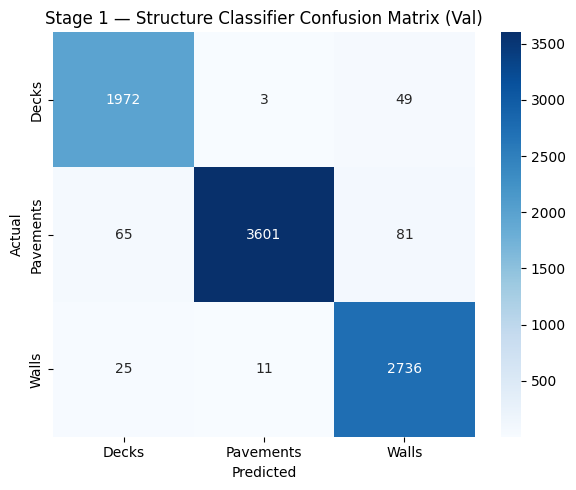

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

s1_val_unshuffled = make_dataset(df_val, 'structure_idx', augment=False, shuffle=False)
s1_preds_prob = structure_model.predict(s1_val_unshuffled, verbose=1)
s1_preds = np.argmax(s1_preds_prob, axis=1)
s1_true  = df_val['structure_idx'].values

cm_s1 = confusion_matrix(s1_true, s1_preds)
acc_s1 = (s1_preds == s1_true).mean()
per_class_recall = cm_s1.diagonal() / cm_s1.sum(axis=1)

print(f'Structure classifier  val accuracy: {acc_s1:.3f}')
for i, struct in enumerate(STRUCTURES):
    print(f'  {struct} recall: {per_class_recall[i]:.3f}')

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_s1, annot=True, fmt='d', cmap='Blues',
    xticklabels=STRUCTURES, yticklabels=STRUCTURES
)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Stage 1 — Structure Classifier Confusion Matrix (Val)')
plt.tight_layout(); plt.show()

## 6. Stage 2 — Per-Structure Defect Classifiers (Recall-Focused)

Three separate binary models (one per structure). Crack appearance differs across surface types, making per-surface models generally more accurate than a single joint model.

**Imbalance handling:** class weights (~3–7× on defect) + threshold tuning on val set.  
**Training objective:** monitor `val_recall` for checkpointing, not `val_loss`.

In [ ]:
THRESHOLD_SWEEP = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
MIN_F1 = 0.60

thresholds = {}

for struct in STRUCTURES:
    print(f'\n{"="*60}')
    print(f'  {struct} — Defect Classifier')
    print(f'{"="*60}')

    df_tr = df_train[df_train['structure'] == struct].reset_index(drop=True)
    df_vl = df_val[df_val['structure'] == struct].reset_index(drop=True)

    n_pos = int((df_tr['defect_idx'] == 1).sum())
    n_neg = int((df_tr['defect_idx'] == 0).sum())
    cw = {0: 1.0, 1: n_neg / n_pos}
    print(f'  Train: {n_pos} defect / {n_neg} no_defect  |  class_weight[defect]={cw[1]:.2f}')

    d_train = make_dataset(df_tr, 'defect_idx', augment=True)
    d_val   = make_dataset(df_vl, 'defect_idx', augment=False, shuffle=False)

    model, base = build_mobilenetv2(num_outputs=1, dropout=0.3, binary=True)

    def compile_defect(m, lr):
        m.compile(
            optimizer=tf.keras.optimizers.Adam(lr),
            loss='binary_crossentropy',
            metrics=[
                'accuracy',
                tf.keras.metrics.Recall(name='recall'),
                tf.keras.metrics.Precision(name='precision'),
            ],
        )

    print('  Phase 1: Head training')
    compile_defect(model, 1e-3)
    model.fit(
        d_train, validation_data=d_val, epochs=EPOCHS_HEAD,
        class_weight=cw,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor='val_recall', patience=3, mode='max', restore_best_weights=True
        )],
        verbose=1,
    )

    print('  Phase 2: Fine-tuning last 20 layers')
    for layer in base.layers[:-20]:
        layer.trainable = False
    for layer in base.layers[-20:]:
        layer.trainable = True

    compile_defect(model, 1e-4)
    model.fit(
        d_train, validation_data=d_val, epochs=EPOCHS_FT,
        class_weight=cw,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor='val_recall', patience=3, mode='max', restore_best_weights=True
        )],
        verbose=1,
    )

    fname = f'models/cnn/defect_model_{struct.lower()}.keras'
    model.save(fname)
    print(f'  Saved {fname}')

    # Threshold tuning on val set
    all_probs, all_labels = [], []
    for imgs, lbls in make_dataset(df_vl, 'defect_idx', augment=False, shuffle=False):
        probs = model.predict(imgs, verbose=0).ravel()
        all_probs.extend(probs.tolist())
        all_labels.extend(lbls.numpy().tolist())
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)

    print(f'\n  Threshold sweep (val set):')
    best_thresh = 0.50
    found = False
    for t in THRESHOLD_SWEEP:
        preds = (all_probs >= t).astype(int)
        rec = recall_score(all_labels, preds, zero_division=0)
        f1  = f1_score(all_labels, preds, zero_division=0)
        print(f'    t={t:.2f}  recall={rec:.3f}  f1={f1:.3f}')
        if f1 >= MIN_F1 and not found:
            best_thresh = t
            found = True

    if not found:
        f1s = [f1_score(all_labels, (all_probs >= t).astype(int), zero_division=0)
               for t in THRESHOLD_SWEEP]
        best_thresh = THRESHOLD_SWEEP[int(np.argmax(f1s))]
        print(f'  WARNING: no threshold achieved F1>={MIN_F1}; using best-F1 threshold.')

    thresholds[struct] = best_thresh
    print(f'  Chosen threshold for {struct}: {best_thresh}')

with open('models/cnn/thresholds.json', 'w') as f:
    json.dump(thresholds, f, indent=2)
print('\nSaved models/cnn/thresholds.json:', thresholds)

## 7. Summary

Models saved: `structure_model.keras`, `defect_model_decks.keras`, `defect_model_pavements.keras`, `defect_model_walls.keras`  
Thresholds saved: `thresholds.json`  
Splits saved: `train_split.csv`, `val_split.csv`, `test_split.csv`

Proceed to `pipeline_eval.ipynb` for recall-focused evaluation on the held-out test set.

In [ ]:
print('=== Training complete ===')
print()
print('Saved artifacts:')
for f in [
    'models/cnn/structure_model.keras',
    'models/cnn/defect_model_decks.keras',
    'models/cnn/defect_model_pavements.keras',
    'models/cnn/defect_model_walls.keras',
    'models/cnn/thresholds.json',
    'splits/train_split.csv',
    'splits/val_split.csv',
    'splits/test_split.csv',
]:
    p = Path(f)
    status = 'OK' if p.exists() else 'MISSING'
    print(f'  [{status}] {f}')
print()
print('Thresholds:', thresholds)